# MCTS sweep — results explorer

Everything here is built from the **`charts`** module (generic, column-name charts) + a few
lines of matplotlib where `charts` has no primitive. Two modules do the work: **`dataset`**
(build/load the parquet) and **`charts`**; **`schema`** documents every column.

**Part 1** rebuilds the five polished *deck* figures (`plots.py`) using only `charts`.
**Part 2** adds other views worth a look. Point the loader below at any run's `trees.parquet`.

## Setup

In [2]:
from dreamerv4uwm.planning.experiments.study.analysis import dataset, charts, schema
import numpy as np, pandas as pd, matplotlib.pyplot as plt
%matplotlib inline
pd.set_option("display.width", 170)

# a run's parquet (build once from shards: dataset.build("<run>/results", out="trees.parquet"))
df = dataset.load("mcts_sweep/mcts_sweep_run1/analysis/trees.parquet")
print(dataset.overview(df))

# swept knobs actually present in this run (numeric + categorical), and the candidate predictors
KNOBS = [k for k in schema.FACTORS if k in df.columns and df[k].nunique(dropna=True) > 1]
METS  = charts.metric_cols(df)
OUT   = "g_random_peak"                      # the headline outcome (swap for g_greedy_peak / tree_peak / delta_over_root)
print(f"{len(KNOBS)} swept knobs: {KNOBS}")
print(f"{len(METS)} candidate predictor metrics")

840 trees  |  21 configs  |  40 inits
g_random success rate: 44.5%
mostly-NaN columns: val_std_depth3
9 swept knobs: ['ctx_noise', 'horizon', 'sim_horizon', 'branching', 'action_temp', 'action_prior', 'c_ucb', 'max_depth', 'n_iterations']
48 candidate predictor metrics


In [3]:
# two small helpers charts doesn't have (a few lines of matplotlib, per the charts philosophy)
def effect_size(knob, y=OUT):
    # max - min of the mean outcome across a knob's OFAT settings (how much the knob moves planning)
    g = charts.ofat(df, knob).groupby(knob, observed=True)[y].mean()
    return float(np.nanmax(g) - np.nanmin(g)) if g.notna().sum() > 1 else 0.0

def binned_rate(x, y=OUT, q=6):
    # success rate (fraction with outcome > 0) within quantile bins of a metric x
    d = df[[x, y]].replace([np.inf, -np.inf], np.nan).dropna()
    d["_b"] = pd.qcut(d[x], q, duplicates="drop")
    g = d.groupby("_b", observed=True)
    return g[x].mean().to_numpy(), g[y].apply(lambda s: (s > 0).mean()).to_numpy()

## Part 1 — the deck, rebuilt from `charts`

### 1a. The headline (`fig_ctxnoise`): diversity rises, but usefulness peaks then cliffs
`charts.response` on the OFAT slice of `ctx_noise` — branch-collapse (diversity) on the left,
planning gain on the right.

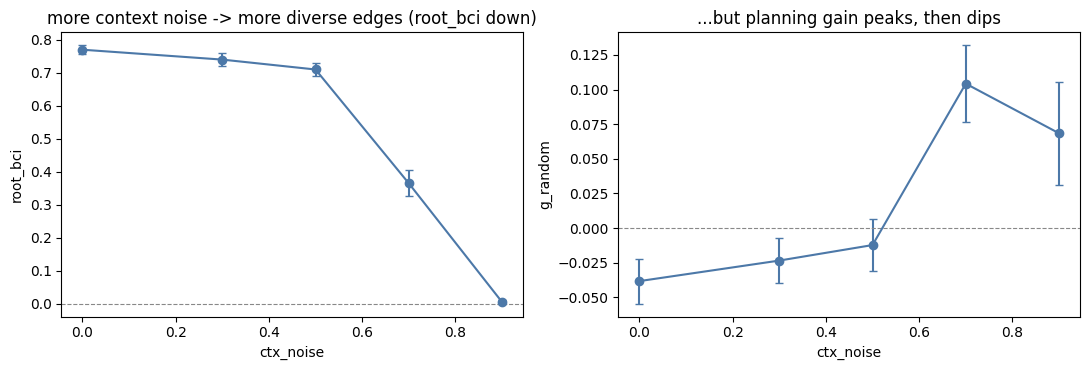

In [4]:
fig, ax = plt.subplots(1, 2, figsize=(11, 3.8))
charts.response(charts.ofat(df, "ctx_noise"), "ctx_noise", "root_bci", ax=ax[0])
charts.response(charts.ofat(df, "ctx_noise"), "ctx_noise", OUT,       ax=ax[1])
ax[0].set_title("more context noise -> more diverse edges (root_bci down)")
ax[1].set_title("...but planning gain peaks, then dips")
fig.tight_layout()

### 1b. Which knobs move planning (`fig_knob_curves`) — one response curve per knob

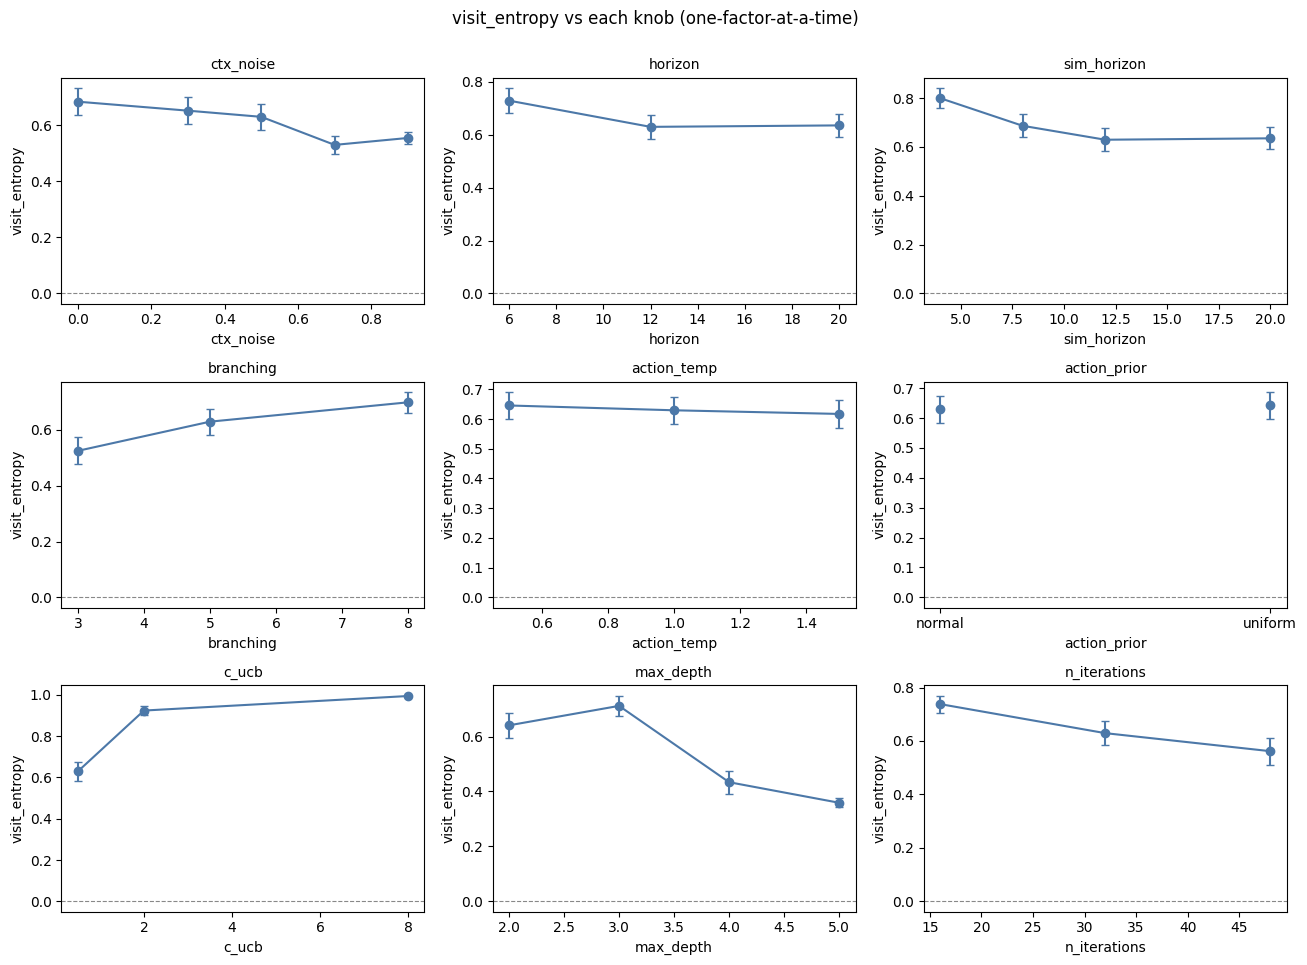

In [5]:
OUT   = "visit_entropy"
n = len(KNOBS); ncol = 3; nrow = int(np.ceil(n / ncol))
fig, axes = plt.subplots(nrow, ncol, figsize=(4.4 * ncol, 3.2 * nrow))
for ax, k in zip(axes.ravel(), KNOBS):
    charts.response(charts.ofat(df, k), k, OUT, ax=ax)     # handles numeric AND categorical knobs
    ax.set_title(k, fontsize=10)
for ax in axes.ravel()[n:]:
    ax.axis("off")
fig.suptitle(f"{OUT} vs each knob (one-factor-at-a-time)", y=1.0); fig.tight_layout()

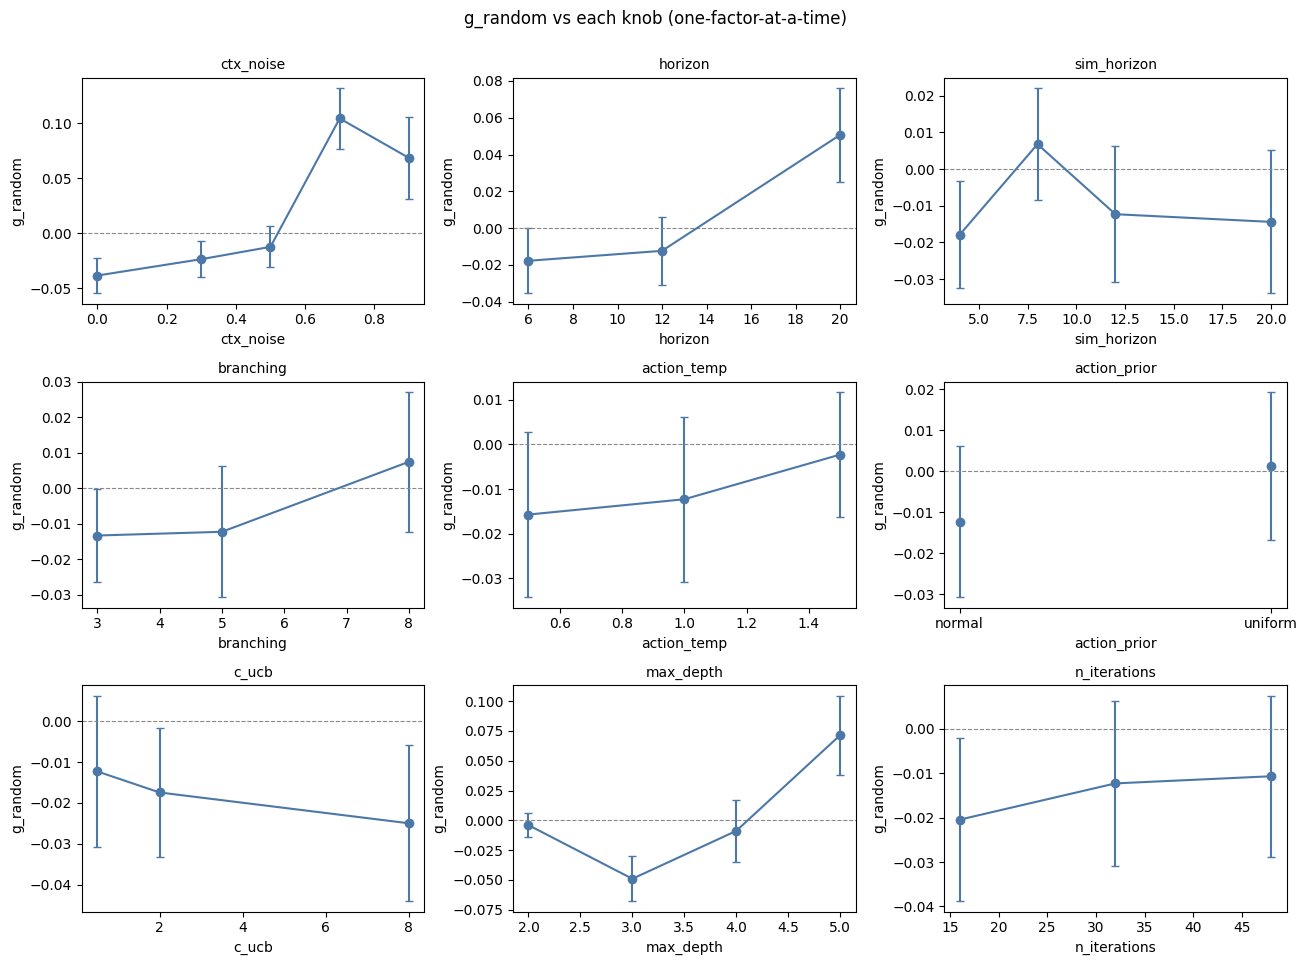

In [6]:
OUT   = "g_random_peak"
n = len(KNOBS); ncol = 3; nrow = int(np.ceil(n / ncol))
fig, axes = plt.subplots(nrow, ncol, figsize=(4.4 * ncol, 3.2 * nrow))
for ax, k in zip(axes.ravel(), KNOBS):
    charts.response(charts.ofat(df, k), k, OUT, ax=ax)     # handles numeric AND categorical knobs
    ax.set_title(k, fontsize=10)
for ax in axes.ravel()[n:]:
    ax.axis("off")
fig.suptitle(f"{OUT} vs each knob (one-factor-at-a-time)", y=1.0); fig.tight_layout()

### 1b'. …and the effect-size bar (`fig_knob_effects`): max−min mean gain per knob

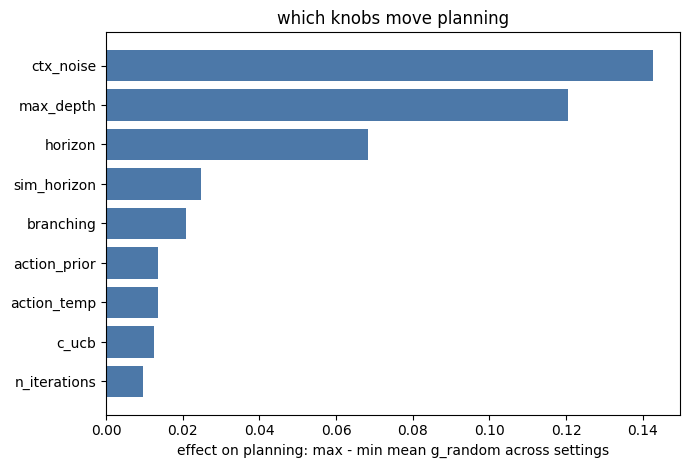

In [7]:
eff = sorted(((k, effect_size(k)) for k in KNOBS), key=lambda t: t[1])
fig, ax = plt.subplots(figsize=(7, 0.42 * len(eff) + 1))
ax.barh([k for k, _ in eff], [e for _, e in eff], color=charts.BLUE)
ax.set_xlabel(f"effect on planning: max - min mean {OUT} across settings")
ax.set_title("which knobs move planning"); fig.tight_layout()

### 1b''. All reward outcomes per knob — multi-line `charts.response`
`charts.response` takes a **list** of outcomes. `tree_peak` is *absolute* reward (0–1) while
`g_random`/`g_greedy` are *relative* to the baselines (~0), so on one axis you see both: where
`tree_peak` moves but the gains stay flat, the knob improves the reached state without beating
the baselines — and where the gains move, search is actually paying off.

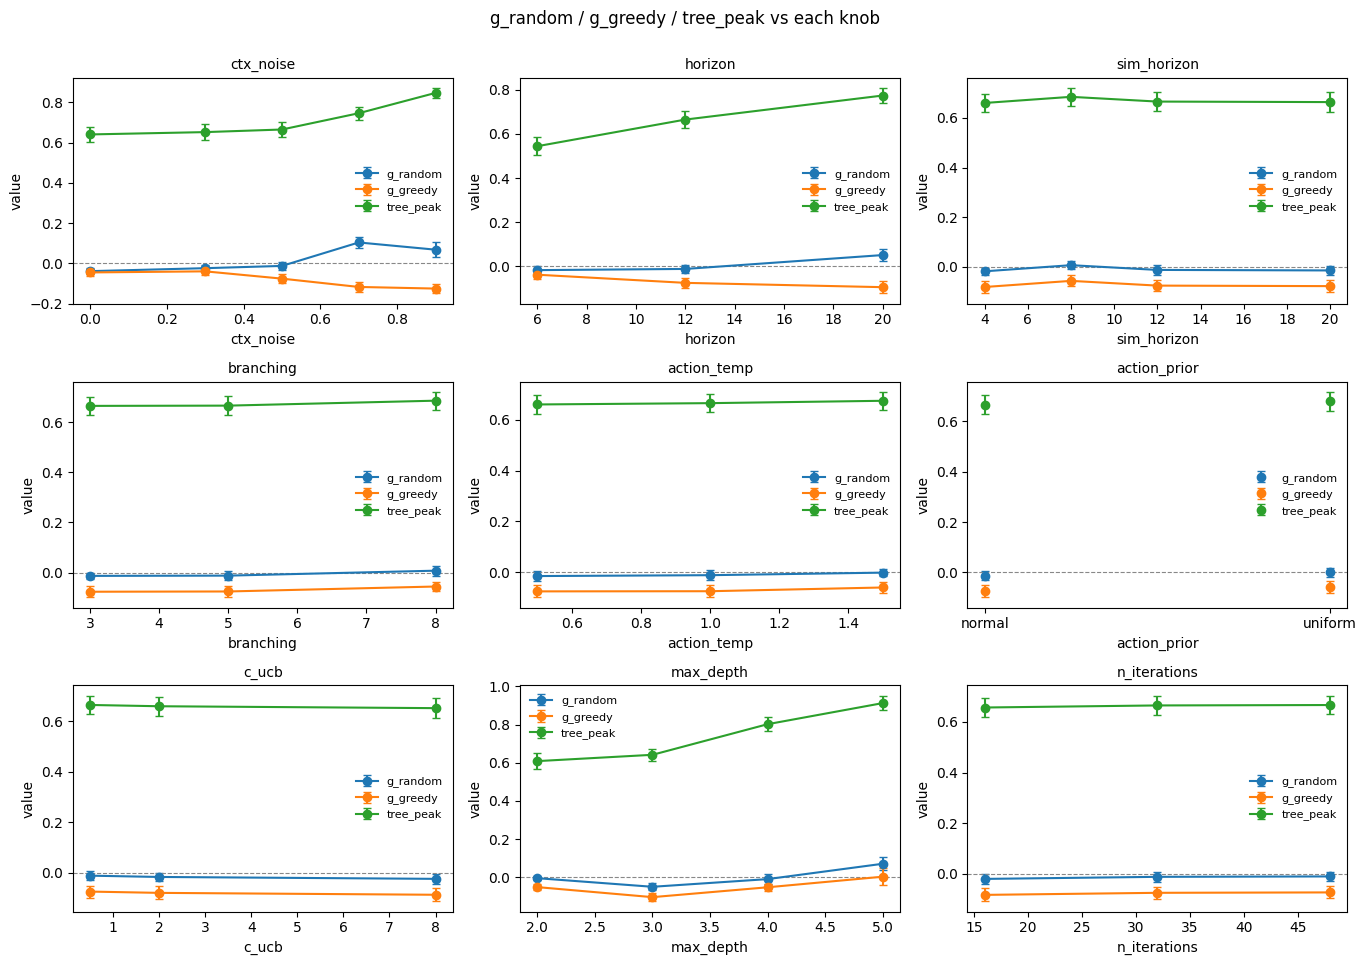

In [8]:
OUTS = ["g_random_peak", "g_greedy_peak", "tree_peak"]
n = len(KNOBS); ncol = 3; nrow = int(np.ceil(n / ncol))
fig, axes = plt.subplots(nrow, ncol, figsize=(4.6 * ncol, 3.2 * nrow))
for ax, k in zip(axes.ravel(), KNOBS):
    charts.response(charts.ofat(df, k), k, OUTS, ax=ax); ax.set_title(k, fontsize=10)
for ax in axes.ravel()[n:]:
    ax.axis("off")
fig.suptitle("g_random_peak / g_greedy_peak / tree_peak vs each knob", y=1.0); fig.tight_layout()

### 1c. What predicts a good tree (`fig_predictors`) — per-tree Spearman with the outcome

<Axes: title={'center': 'what predicts g_random'}, xlabel='Spearman correlation with g_random'>

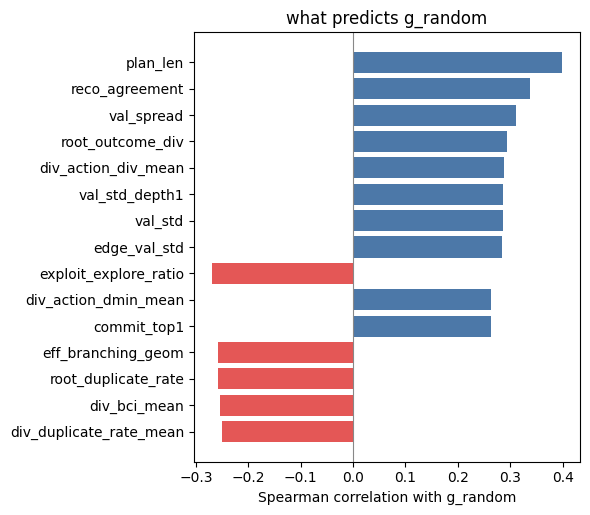

In [9]:
charts.corr_bars(df, OUT, top=15)

### 1d. The mechanism (`fig_mechanism`): edge-reward diversity → planning gain
Left: one dot per tree (coloured by `ctx_noise`). Right: success rate binned by the same metric.

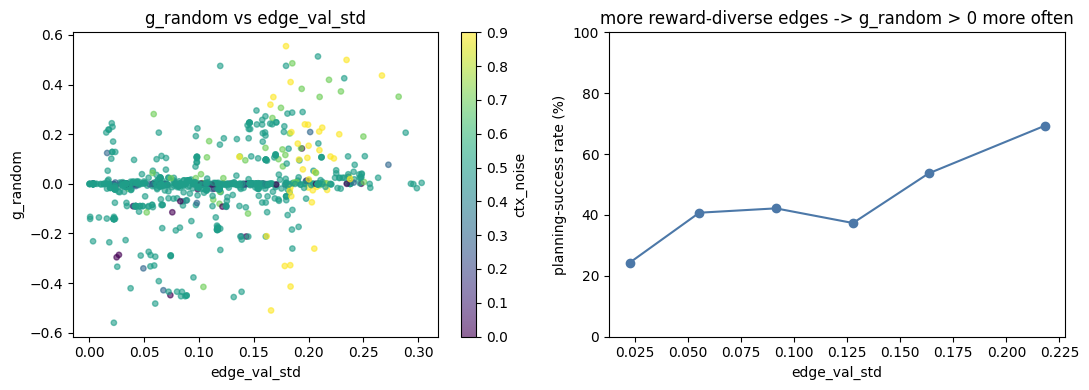

In [10]:
fig, ax = plt.subplots(1, 2, figsize=(11, 4))
charts.scatter(df, "edge_val_std", OUT, color="ctx_noise", ax=ax[0])
x, rate = binned_rate("edge_val_std")
ax[1].plot(x, 100 * rate, "o-", color=charts.BLUE)
ax[1].set(xlabel="edge_val_std", ylabel="planning-success rate (%)",
          title=f"more reward-diverse edges -> {OUT} > 0 more often"); ax[1].set_ylim(0, 100)
fig.tight_layout()

## Part 2 — other views worth a look

### 2a. Outcome distributions
Where do the gains actually land? (0 line = "no better than the baseline"; 0.7 = a well-centred T.)

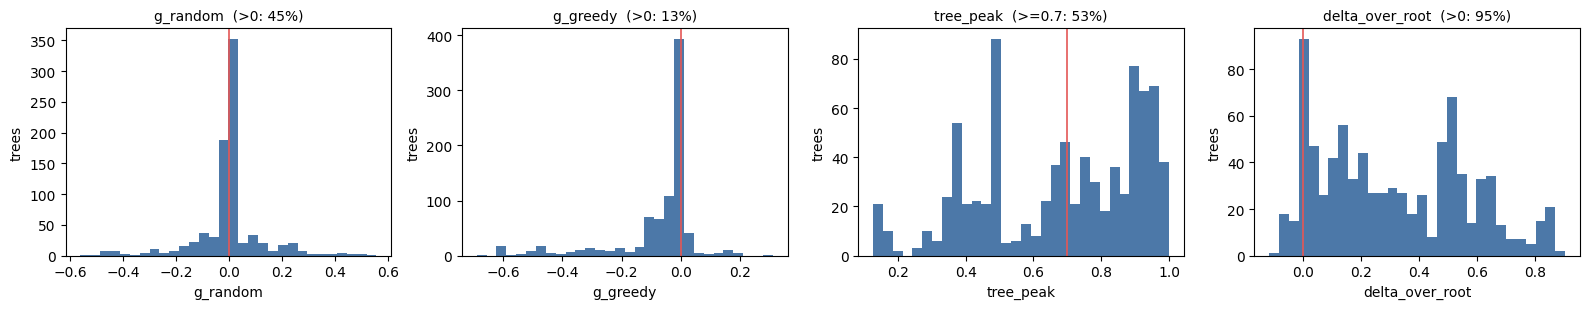

In [11]:
cols = ["g_random_peak", "g_greedy_peak", "tree_peak", "delta_over_root"]
fig, axes = plt.subplots(1, 4, figsize=(16, 3.2))
for ax, c in zip(axes, cols):
    if c not in df.columns: ax.axis("off"); continue
    charts.hist(df, c, ax=ax)
    if c in ("g_random_peak", "g_greedy_peak", "delta_over_root"):
        ax.axvline(0, color=charts.RED, lw=1.2)
        ax.set_title(f"{c}  (>0: {(df[c] > 0).mean():.0%})", fontsize=10)
    if c == "tree_peak":
        ax.axvline(0.7, color=charts.RED, lw=1.2)
        ax.set_title(f"tree_peak  (>=0.7: {(df[c] >= 0.7).mean():.0%})", fontsize=10)
fig.tight_layout()

### 2b. The two bars: `g_random` (vs one rollout) vs `g_greedy` (vs best-of-N shooting)
`g_greedy` is the harder test. Points above the diagonal = beat a single rollout but not shooting.

Text(0.5, 1.0, 'g_random vs g_greedy (dashed = equal)')

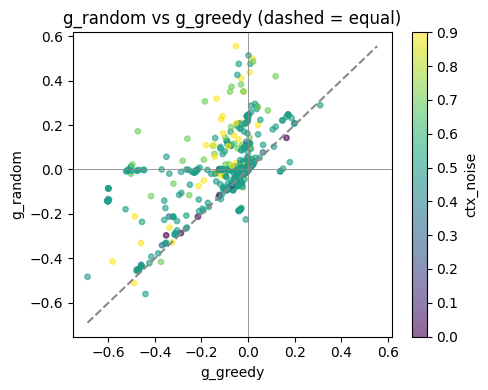

In [12]:
ax = charts.scatter(df, "g_greedy_peak", "g_random_peak", color="ctx_noise")
lim = [min(df.g_greedy_peak.min(), df.g_random_peak.min()), max(df.g_greedy_peak.max(), df.g_random_peak.max())]
ax.plot(lim, lim, ls="--", color=charts.GREY); ax.axhline(0, color=charts.GREY, lw=0.6); ax.axvline(0, color=charts.GREY, lw=0.6)
ax.set_title("g_random_peak vs g_greedy_peak (dashed = equal)")

### 2c. What predicts each outcome — compare `g_random` and `g_greedy`

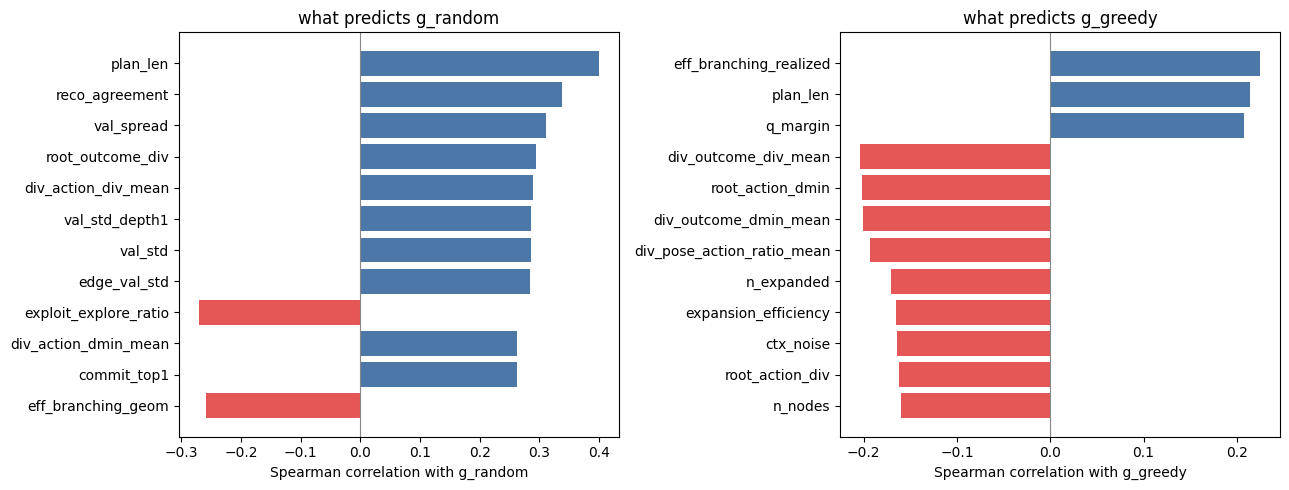

In [13]:
fig, ax = plt.subplots(1, 2, figsize=(13, 5))
charts.corr_bars(df, "g_random_peak", top=12, ax=ax[0])
charts.corr_bars(df, "g_greedy_peak", top=12, ax=ax[1])
fig.tight_layout()

### 2d. The causal chain at a glance — one headline metric per L1–L5 link vs the outcome
(L1 action diversity, L2 outcome diversity, L3 value spread, L4 exploit/explore, L5 subtree Gini.)

/home/mim-server/projects/felix/dreamerV4-UWM/dreamerv4uwm/planning/experiments/study/analysis/charts.py:101: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  sc = ax.scatter(d[x], d[y], c=(d[color] if color else BLUE), cmap="viridis", s=15, alpha=0.6)
/home/mim-server/projects/felix/dreamerV4-UWM/dreamerv4uwm/planning/experiments/study/analysis/charts.py:101: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  sc = ax.scatter(d[x], d[y], c=(d[color] if color else BLUE), cmap="viridis", s=15, alpha=0.6)
/home/mim-server/projects/felix/dreamerV4-UWM/dreamerv4uwm/planning/experiments/study/analysis/charts.py:101: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  sc = ax.scatter(d[x], d[y], c=(d[color] if color else BLUE), cmap="viridis", s=15, alpha=0.6)
/home/mim-server/projects/felix/dreamerV4-UWM/dreamerv4uwm/planning/experiments/study/analysis/charts.py:101: Us

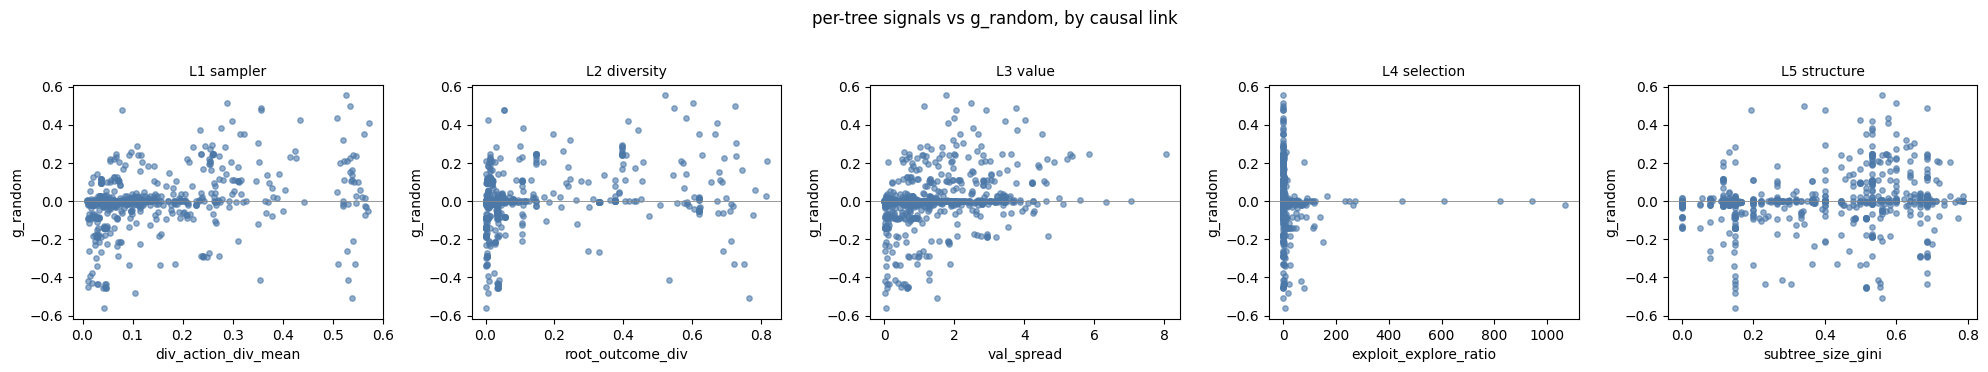

In [14]:
chain = [("div_action_div_mean", "L1 sampler"), ("root_outcome_div", "L2 diversity"),
         ("val_spread", "L3 value"), ("exploit_explore_ratio", "L4 selection"),
         ("subtree_size_gini", "L5 structure")]
chain = [(m, lab) for m, lab in chain if m in df.columns]
fig, axes = plt.subplots(1, len(chain), figsize=(4 * len(chain), 3.6))
for ax, (m, lab) in zip(np.atleast_1d(axes), chain):
    charts.scatter(df, m, OUT, ax=ax); ax.axhline(0, color=charts.GREY, lw=0.6); ax.set_title(lab, fontsize=10)
fig.suptitle(f"per-tree signals vs {OUT}, by causal link", y=1.02); fig.tight_layout()

### 2e. Correlation structure — the outcome + one metric per link

<Axes: >

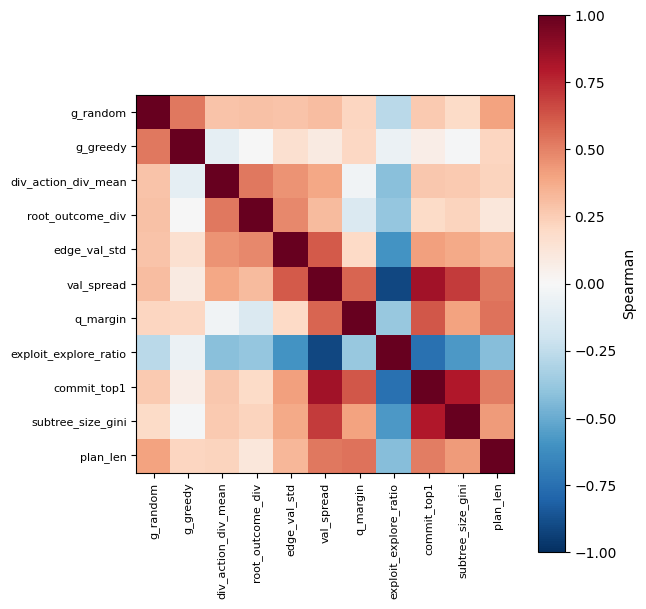

In [15]:
hm = ["g_random_peak", "g_greedy_peak", "div_action_div_mean", "root_outcome_div", "edge_val_std",
      "val_spread", "q_margin", "exploit_explore_ratio", "commit_top1", "subtree_size_gini", "plan_len"]
charts.heatmap(df, [c for c in hm if c in df.columns])

### 2f. Does more compute pay off? (gain vs world-model calls / iterations)

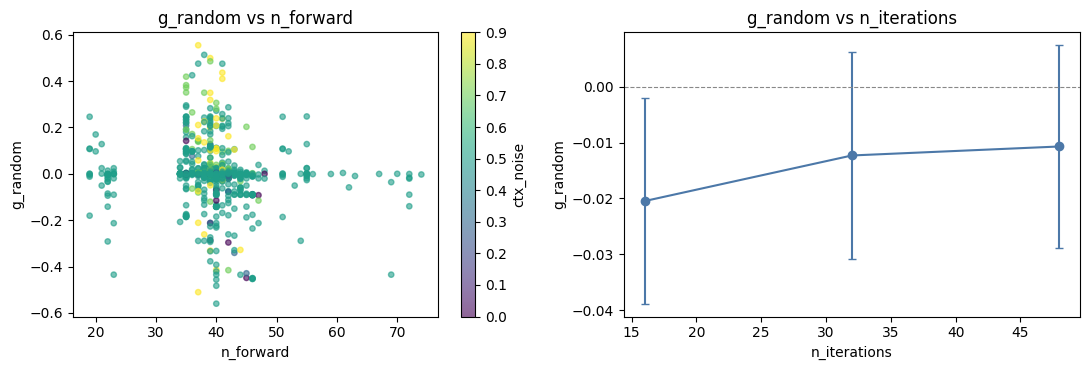

In [16]:
fig, ax = plt.subplots(1, 2, figsize=(11, 3.8))
charts.scatter(df, "n_forward", OUT, color="ctx_noise", ax=ax[0])
if "n_iterations" in KNOBS:
    charts.response(charts.ofat(df, "n_iterations"), "n_iterations", OUT, ax=ax[1])
else:
    ax[1].axis("off")
fig.tight_layout()

### 2g. Diversity -> reliability: planning-success rate vs branch-collapse (root)
Low `root_bci` (edges stay distinct) should mean planning helps more often.

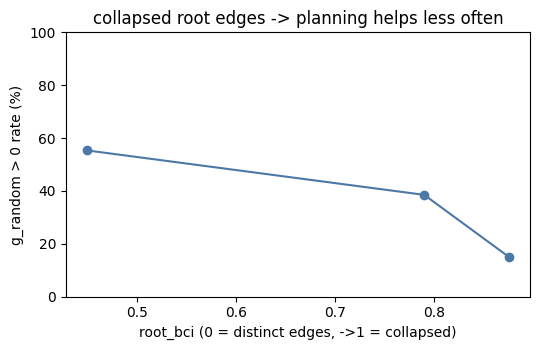

In [17]:
x, rate = binned_rate("root_bci")
fig, ax = plt.subplots(figsize=(5.5, 3.6))
ax.plot(x, 100 * rate, "o-", color=charts.BLUE)
ax.set(xlabel="root_bci (0 = distinct edges, ->1 = collapsed)", ylabel=f"{OUT} > 0 rate (%)",
       title="collapsed root edges -> planning helps less often"); ax.set_ylim(0, 100)
fig.tight_layout()

## Reference — what every column means

In [18]:
with pd.option_context("display.max_rows", None, "display.max_colwidth", 100):
    display(schema.data_dictionary(df))

,column,kind,link,dtype,description
0,config_id,meta,,int64,index of the config in the sweep (0..n_configs-1)
1,config_tag,meta,,str,human tag of the config: 'base' or 'ofat.<knob>=<value>'
2,descriptor_kind,meta,,str,diversity descriptor: pose (axis theta) | heading (up/down-resolved)
3,dtype,meta,,str,autocast dtype used for the rollouts (bfloat16)
4,init_id,meta,,int64,index of the curated initial state (decision point)
5,plan_secs,meta,,float64,wall-clock seconds spent building this tree
6,plan_seed,meta,,int64,RNG seed of the planner for this tree
7,reward_kind,meta,,str,reward that scored this tree: center | straight (axis) | angle (upright)
8,t0,meta,,int64,frame offset inside that window where the Tc-frame context starts
9,window_idx,meta,,int64,dataset index of the demo window the initial context came from
